# Predicting Medical Insurace Charges
# *(Using Linear Regression)*

# ________________________________________________________________________

## Importing Dependencies

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Importing Dataset

In [58]:
insurance_data=pd.read_csv('insurance.csv')

## Data Analysis

In [3]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [43]:
insurance_data.shape

(1338, 7)

In [4]:
print(insurance_data['sex'].value_counts())
print(insurance_data['smoker'].value_counts())
print(insurance_data['region'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [6]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Visualization

<Figure size 600x600 with 0 Axes>

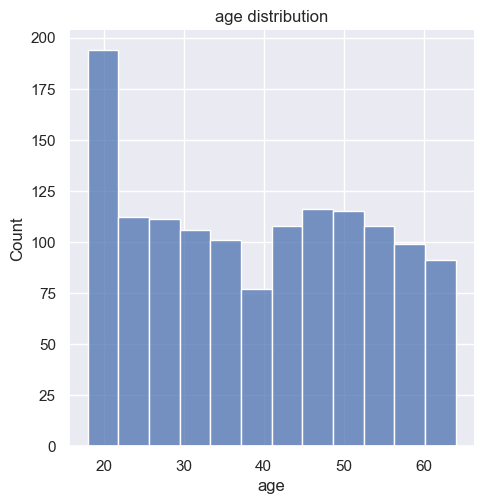

In [22]:
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_data['age'])
plt.title('age distribution')
plt.show()

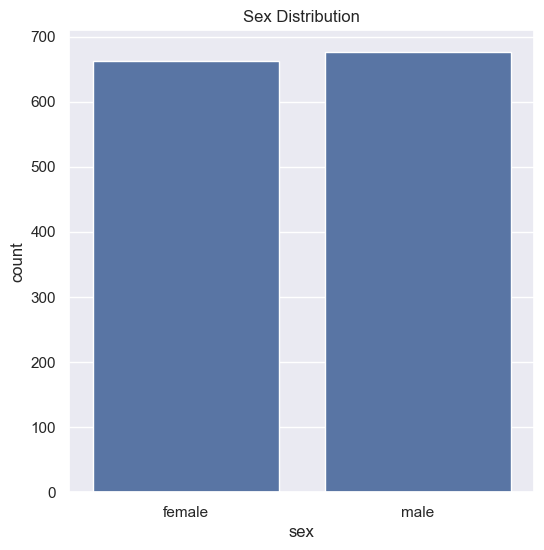

In [24]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex',data=insurance_data)
plt.title('Sex Distribution')
plt.show()

<Figure size 600x600 with 0 Axes>

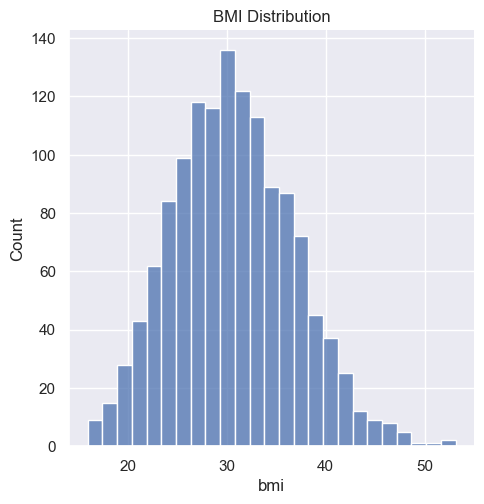

In [25]:
plt.figure(figsize=(6,6))
sns.displot(insurance_data['bmi'])
plt.title('BMI Distribution')
plt.show()

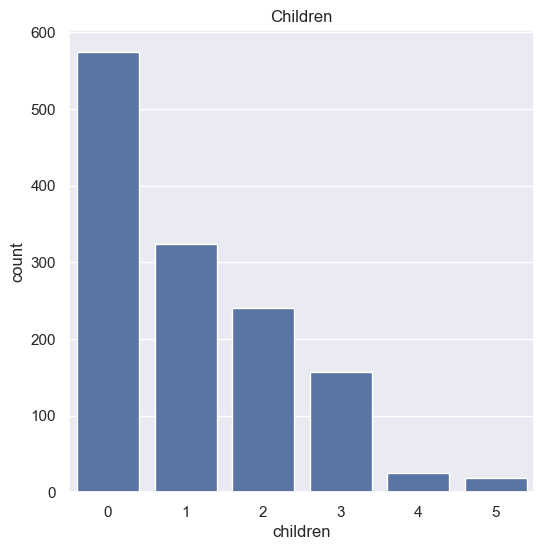

In [26]:
plt.figure(figsize=(6,6))
sns.countplot(x='children',data=insurance_data)
plt.title('Children')
plt.show()

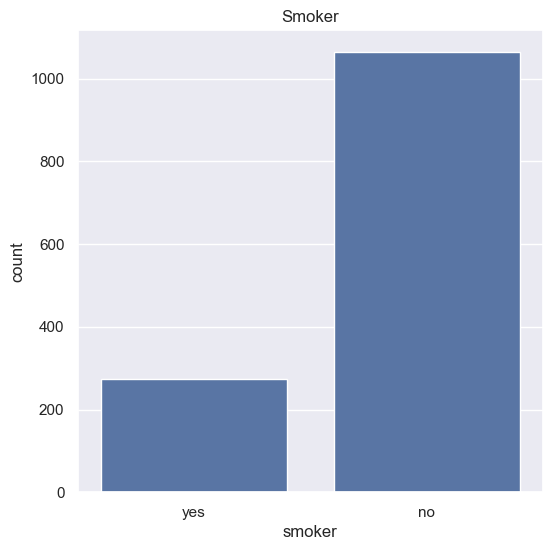

In [27]:
plt.figure(figsize=(6,6))
sns.countplot(x='smoker',data=insurance_data)
plt.title('Smoker')
plt.show()

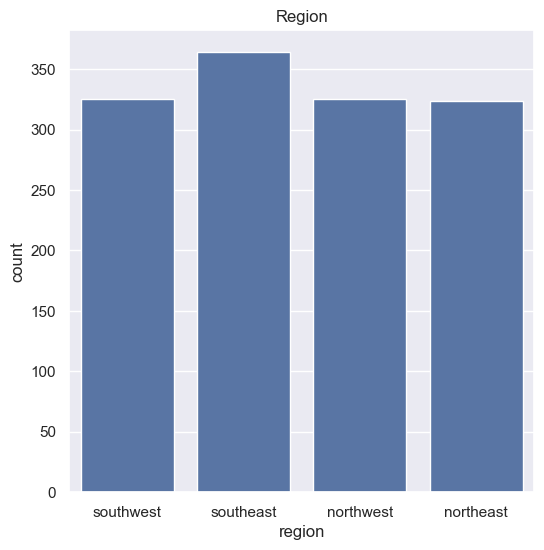

In [28]:
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=insurance_data)
plt.title('Region')
plt.show()

<Figure size 600x600 with 0 Axes>

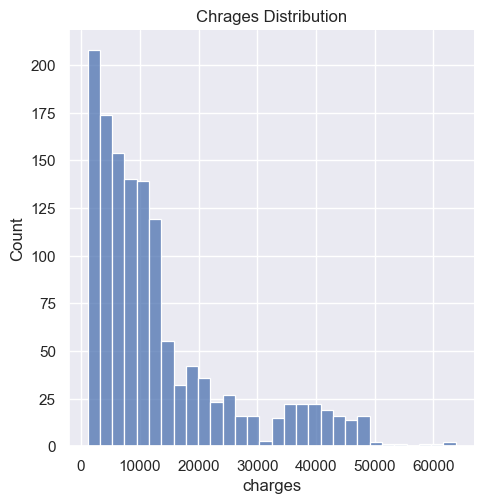

In [30]:
plt.figure(figsize=(6,6))
sns.displot(insurance_data['charges'])
plt.title('Chrages Distribution')
plt.show()

## Categorical Feature Encoding

In [37]:
insurance_data.replace({'sex':{'male':1,'female':0}},inplace=True)
insurance_data.replace({'smoker':{'yes':1,'no':0}},inplace=True)
insurance_data.replace({'region':{'southeast':0,'southwest':1,'northwest':2,'northeast':3}},inplace=True)

C:\Users\thora\AppData\Local\Temp\ipykernel_18112\2480457277.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_data.replace({'region':{'southeast':0,'southwest':1,'northwest':2,'northeast':3}},inplace=True)


In [38]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,0,1725.55230
2,28,1,33.000,3,0,0,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


## Splitting Training and Test Data

In [39]:
X=insurance_data.drop(columns={'charges'})
Y=insurance_data['charges']

In [40]:
print(X)
print(Y)

      age  sex     bmi  children  smoker  region
0      19    0  27.900         0       1       1
1      18    1  33.770         1       0       0
2      28    1  33.000         3       0       0
3      33    1  22.705         0       0       2
4      32    1  28.880         0       0       2
...   ...  ...     ...       ...     ...     ...
1333   50    1  30.970         3       0       2
1334   18    0  31.920         0       0       3
1335   18    0  36.850         0       0       0
1336   21    0  25.800         0       0       1
1337   61    0  29.070         0       1       2

[1338 rows x 6 columns]
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [49]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [50]:
print(x_train)
print(y_train)

      age  sex     bmi  children  smoker  region
882    21    0  22.135         0       0       3
505    37    1  30.875         3       0       2
798    58    0  33.100         0       0       1
792    22    0  23.180         0       0       3
201    48    0  32.230         1       0       0
...   ...  ...     ...       ...     ...     ...
466    60    0  28.700         1       0       1
299    48    0  28.880         1       0       2
493    61    1  43.400         0       0       1
527    51    0  25.800         1       0       1
1192   58    0  32.395         1       0       3

[1070 rows x 6 columns]
882      2585.85065
505      6796.86325
798     11848.14100
792      2731.91220
201      8871.15170
           ...     
466     13224.69300
299      9249.49520
493     12574.04900
527      9861.02500
1192    13019.16105
Name: charges, Length: 1070, dtype: float64


## Model Training

In [51]:
model=LinearRegression()

In [52]:
model.fit(x_train,y_train)

LinearRegression()

## Making Prediction

In [53]:
prediction=model.predict(x_test)

## Model Evaluation

In [55]:
r2_score=metrics.r2_score(y_test,prediction)
print(r2_score)

0.7454471618659975


## Building Pridictive System

In [57]:
input_data = (31,1,25.74,0,1,0)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

print('The insurance cost is USD ', prediction[0])

[27524.88981206]
The insurance cost is USD  27524.889812064655


C:\Users\thora\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
